## Импорт библиотек

In [842]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [843]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [844]:
# from google.colab import drive
# drive.mount('/content/drive')

In [845]:
# df = pd.read_csv('/content/drive/MyDrive/Colab/Курсовая, 3 курс/После обработки/ERA5_full.csv', parse_dates=['date'])
# era5 = pd.read_csv('/content/drive/MyDrive/Colab/Курсовая, 3 курс/После обработки/ERA5_full.csv', parse_dates=['date'])

In [846]:
df = pd.read_csv('climat_official.csv', parse_dates=['date'])
era5 = pd.read_csv('ERA5_full.csv', parse_dates=['date'])

In [847]:
df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.25,10.00,10.000,8.00,8.000,0.00,...,0,0,0,0,0,0,0,0,0,0
1,34152,1981-01-01,-0.1,0.4,71.00,10.00,7.500,8.00,7.000,0.00,...,0,0,0,0,0,0,0,0,0,0
2,34163,1981-01-01,-1.0,0.4,80.00,10.00,7.500,8.00,6.250,0.00,...,0,0,0,0,0,0,0,0,0,0
3,34172,1981-01-01,0.4,0.0,70.00,10.00,8.750,8.00,7.250,0.00,...,0,0,0,0,0,0,0,0,0,0
4,34186,1981-01-01,-3.6,1.0,24.50,9.75,8.625,6.25,6.375,2.25,...,0,0,0,0,0,0,0,0,0,0


In [848]:
era5.head()

,Индекс ВМО,date,latitude,longitude,2m_dewpoint_temperature_stream-oper_daily-mean,2m_temperature_0_daily-mean,surface_pressure_0_daily-mean,total_precipitation_0_daily-mean,maximum_2m_temperature_since_previous_post_processing_0_daily-mean,skin_temperature_0_daily-mean,mean_evaporation_rate_0_daily-mean,clear_sky_direct_solar_radiation_at_surface_0_daily-mean,evaporation_0_daily-mean,potential_evaporation_0_daily-mean,convective_precipitation_0_daily-mean,avg_pevr,avg_cpr,total_precipitation_scaled
0,34059,1940-01-01,52.0,43.65,-17.98183,-15.66160,99108.64,0.006866,-15.46342,-15.76063,-6.382252e-08,143130.860,-0.000235,-0.022892,0.0,-0.006360,0.0,-0.059208
1,34059,1940-01-02,52.0,43.65,-25.21587,-22.83079,99859.69,0.000119,-22.02915,-24.17704,2.240773e-07,114577.516,0.000809,-0.005217,0.0,-0.001451,0.0,-0.231404
2,34059,1940-01-03,52.0,43.65,-28.55027,-26.00974,99506.39,0.003672,-25.81016,-27.42121,2.444089e-07,112423.450,0.000887,-0.008524,0.0,-0.002368,0.0,-0.140737
3,34059,1940-01-04,52.0,43.65,-23.95266,-21.39904,99039.92,0.145149,-21.49006,-21.82960,3.162277e-07,105748.640,0.001139,-0.017972,0.0,-0.004992,0.0,3.470007
4,34059,1940-01-05,52.0,43.65,-15.92990,-14.26237,98507.39,0.070214,-14.27793,-15.25153,1.394192e-06,113422.200,0.005017,-0.022017,0.0,-0.006115,0.0,1.557536


In [849]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112035 entries, 0 to 112034
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       112035 non-null  int64         
 1   date                                             112035 non-null  datetime64[ns]
 2   Средняя температура воздуха                      112035 non-null  float64       
 3   Количество осадков                               112035 non-null  float64       
 4   Горизонтальная дальность видимости               112035 non-null  float64       
 5   Общее количество облачности                      112035 non-null  float64       
 6   Количество облачности нижнего яруса              112035 non-null  float64       
 7   Форма облаков верхнего яруса                     112035 non-null  float64       
 8   Форма облаков среднего я

In [850]:
df.isna().sum()

Индекс ВМО                                            0
date                                                  0
Средняя температура воздуха                           0
Количество осадков                                    0
Горизонтальная дальность видимости                    0
Общее количество облачности                           0
Количество облачности нижнего яруса                   0
Форма облаков верхнего яруса                          0
Форма облаков среднего яруса                          0
Форма облаков вертикального развития                  0
Слоистые и слоисто-кучевые облака                     0
Слоисто-дожд,разорванно-дождевые облака               0
Высота нижней границы облачности                   1106
Погода между сроками                                  0
Погода в срок наблюдения                              0
Направление ветра                                     0
Средняя скорость ветра                                0
Максимальная скорость ветра                     

In [851]:
df = df.interpolate()

In [852]:
df.isna().sum()

Индекс ВМО                                         0
date                                               0
Средняя температура воздуха                        0
Количество осадков                                 0
Горизонтальная дальность видимости                 0
Общее количество облачности                        0
Количество облачности нижнего яруса                0
Форма облаков верхнего яруса                       0
Форма облаков среднего яруса                       0
Форма облаков вертикального развития               0
Слоистые и слоисто-кучевые облака                  0
Слоисто-дожд,разорванно-дождевые облака            0
Высота нижней границы облачности                   0
Погода между сроками                               0
Погода в срок наблюдения                           0
Направление ветра                                  0
Средняя скорость ветра                             0
Максимальная скорость ветра                        0
Сумма осадков                                 

In [853]:
# Очистка от спец символов
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace('-', '_', regex=False)  # дефис → _
        .str.replace(',', '', regex=False)  # запятая → удалить
    )

    return df


df = clean_columns(df)

In [854]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112035 entries, 0 to 112034
Data columns (total 51 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      112035 non-null  int64         
 1   date                                            112035 non-null  datetime64[ns]
 2   Средняя температура воздуха                     112035 non-null  float64       
 3   Количество осадков                              112035 non-null  float64       
 4   Горизонтальная дальность видимости              112035 non-null  float64       
 5   Общее количество облачности                     112035 non-null  float64       
 6   Количество облачности нижнего яруса             112035 non-null  float64       
 7   Форма облаков верхнего яруса                    112035 non-null  float64       
 8   Форма облаков среднего яруса      

## Разделение на тренировчную/валидационную/тестовую

In [855]:
df.groupby('Индекс ВМО')['date'].count()

Индекс ВМО
34059    16005
34152    16005
34163    16005
34172    16005
34186    16005
34289    16005
34391    16005
Name: date, dtype: int64

На каждый индекс станции есть день

In [856]:
df.shape

(112035, 51)

In [857]:
df.date.min(), df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-10-26 00:00:00'))

In [858]:
# границы
test_start = df['date'].max() - pd.DateOffset(months=1)
val_start = test_start - pd.DateOffset(months=1)
val_start, test_start

(Timestamp('2024-08-26 00:00:00'), Timestamp('2024-09-26 00:00:00'))

In [859]:
train_df = df[df['date'] < val_start]
val_df = df[(df['date'] >= val_start) & (df['date'] < test_start)]
test_df = df[df['date'] >= test_start]

In [860]:
train_df.shape, val_df.shape, test_df.shape

((111601, 51), (217, 51), (217, 51))

In [861]:
217 / 7

31.0

1 месяц

### Делаем значения Nan чтобы не было утечек

In [862]:
old_val_df = val_df.copy()  # Понадобится для восстановления

In [863]:
test_df_nan = test_df.copy()

Всё кроме даты и индекса

In [864]:
# cols_to_nan = [c for c in val_df.columns if c not in ['date', 'Индекс ВМО']]

cols_to_nan = [
    c for c in val_df.columns
    if c not in ['date', 'Индекс ВМО']
       and not c.endswith('_missing')
]

val_df[cols_to_nan] = np.nan
test_df_nan[cols_to_nan] = np.nan

In [865]:
val_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111601,34059,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111602,34152,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111603,34163,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111604,34172,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111605,34186,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [866]:
test_df_nan.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111818,34059,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111819,34152,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111820,34163,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111821,34172,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111822,34186,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1


## Добавление лагов

In [867]:
# Соеднияем всё в один датасет(Вал и тест - Nan)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df = train_val_df.sort_values(['Индекс ВМО', 'date'])

In [868]:
train_val_df.date.min(), train_val_df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [869]:
original_cols = [col for col in df.columns if col not in ['Индекс ВМО', 'date']]

### Общие лаги

In [870]:
train_val_df.shape

(111818, 51)

### Лаги за последние года для коррелируемых


In [871]:
train_val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111818 entries, 0 to 111817
Data columns (total 51 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      111818 non-null  int64         
 1   date                                            111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                     111601 non-null  float64       
 3   Количество осадков                              111601 non-null  float64       
 4   Горизонтальная дальность видимости              111601 non-null  float64       
 5   Общее количество облачности                     111601 non-null  float64       
 6   Количество облачности нижнего яруса             111601 non-null  float64       
 7   Форма облаков верхнего яруса                    111601 non-null  float64       
 8   Форма облаков среднего яруса           

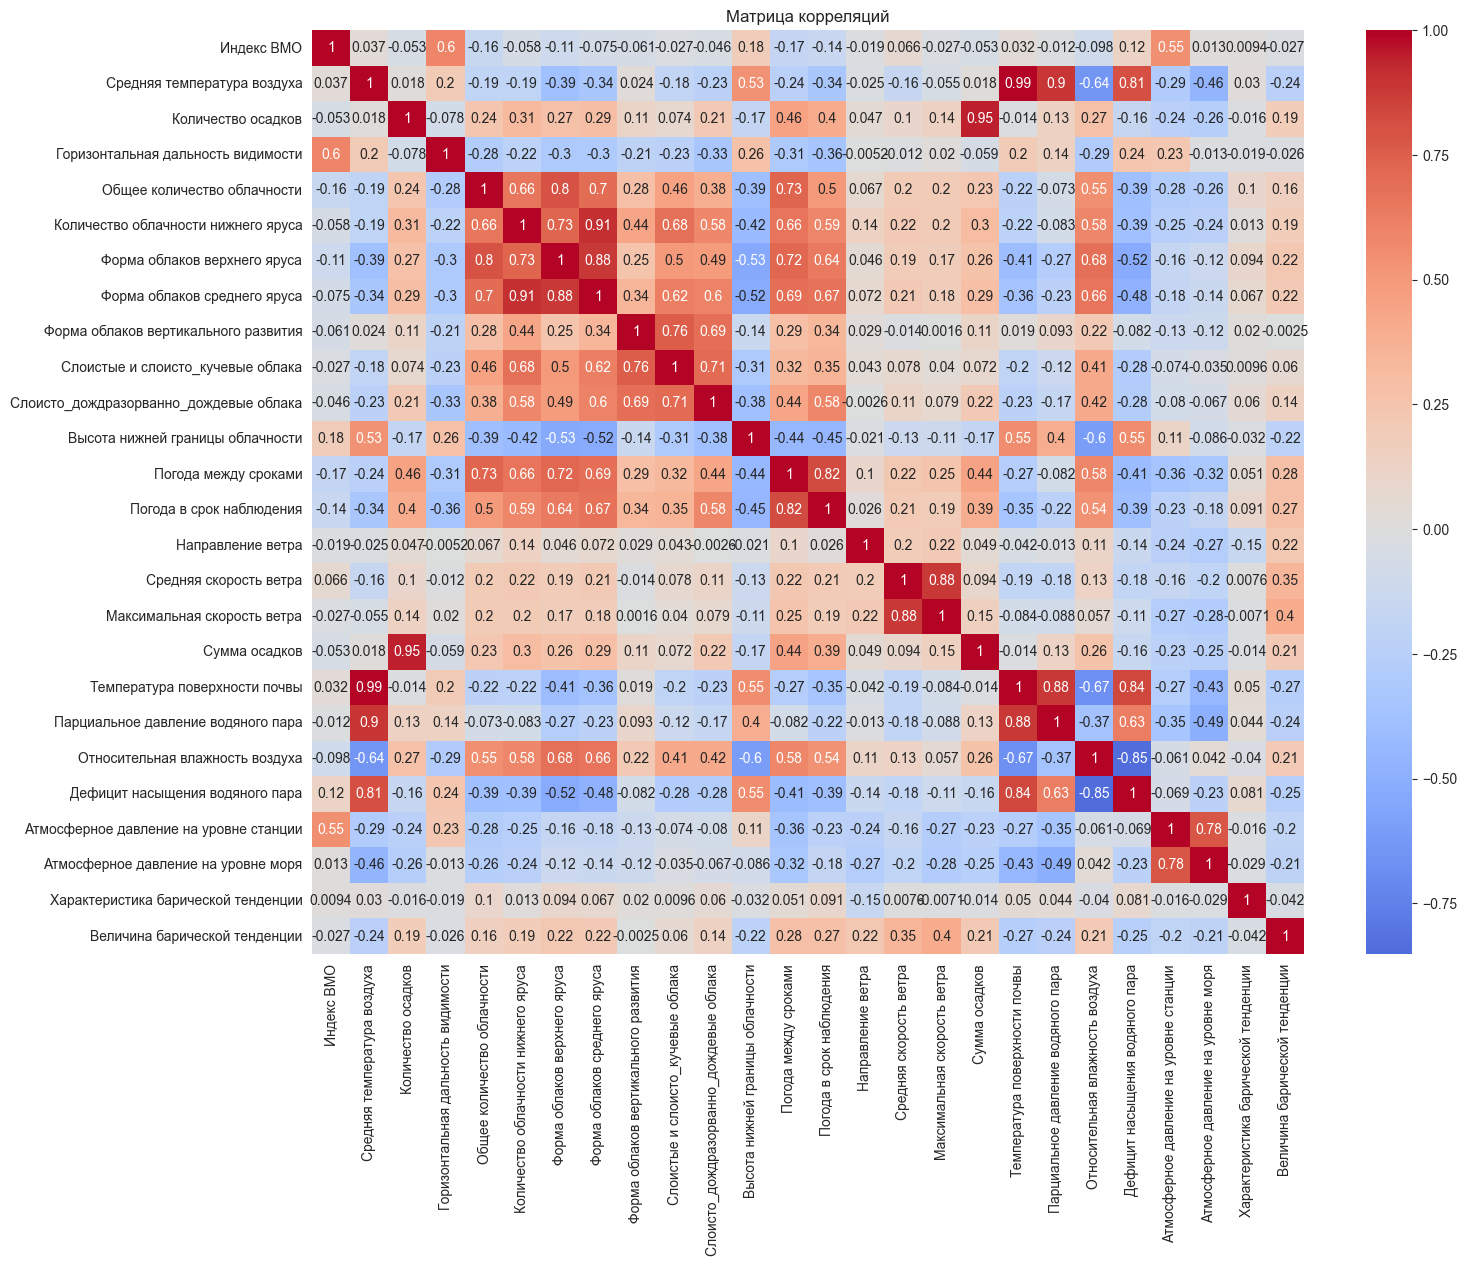

In [872]:
corr_df = train_val_df.select_dtypes(include=['number'])

cols = [col for col in corr_df.columns if not col.endswith('_missing')]
corr_df = corr_df[cols]

corr_matrix = corr_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True)
plt.title('Матрица корреляций')
plt.show()

In [873]:
target_corr = corr_matrix['Средняя температура воздуха'].sort_values(ascending=False)
print(target_corr)

Средняя температура воздуха               1.000000
Температура поверхности почвы             0.986253
Парциальное давление водяного пара        0.895859
Дефицит насыщения водяного пара           0.808318
Высота нижней границы облачности          0.532021
Горизонтальная дальность видимости        0.203328
Индекс ВМО                                0.036588
Характеристика барической тенденции       0.030477
Форма облаков вертикального развития      0.024275
Количество осадков                        0.018090
Сумма осадков                             0.017701
Направление ветра                        -0.025096
Максимальная скорость ветра              -0.054944
Средняя скорость ветра                   -0.163007
Слоистые и слоисто_кучевые облака        -0.180064
Количество облачности нижнего яруса      -0.194053
Общее количество облачности              -0.194740
Слоисто_дождразорванно_дождевые облака   -0.225537
Величина барической тенденции            -0.243237
Погода между сроками           

#### Создаём лаги на год для ключевых признаков только

In [874]:
key_features = [
    'Средняя температура воздуха',
    'Температура поверхности почвы',
    'Парциальное давление водяного пара',
    'Относительная влажность воздуха',
    'Дефицит насыщения водяного пара',
    'Атмосферное давление на уровне моря',
    'Атмосферное давление на уровне станции'
]

In [875]:
seasonal_lags = [335, 365, 395]

In [876]:
for col in key_features:
    for lag in seasonal_lags:
        train_val_df[f'{col}_lag_{lag}'] = (
            train_val_df
            .groupby('Индекс ВМО')[col]
            .shift(lag)
        )

### Функция лагов для конкретного дня

In [877]:
def create_lags(df, index_col='Индекс ВМО', date_col='date'):
    # print(df.date.min(), df.date.max())
    # lagged_df = df.copy()
    #
    # # Выбираем колонки для лагов
    # short_lags = [1, 2, 3]
    # cols_to_short_lag = [col for col in lagged_df.columns if col not in [index_col, date_col]]
    # for lag in short_lags:
    #     for col in cols_to_short_lag:
    #         lagged_df[f'{col}_short_lag{lag}'] = lagged_df.groupby(index_col)[col].shift(lag)
    #
    # return lagged_df

    return df

In [878]:
lagged_df = create_lags(train_val_df)
# lagged_df.tail(40)
lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
111789,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.125,2.60750,11.29375,8.3375,1023.3750,1029.3000,1008.7750,1020.3750,1026.4125,1005.9750
111796,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.125,3.41000,11.48750,7.5125,1017.6375,1031.1000,1008.3875,1014.7000,1028.2000,1005.5875
111803,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.250,2.41000,12.80000,7.8625,1005.0125,1030.0000,1009.4125,1002.1250,1027.1125,1006.6125
111810,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.000,2.28875,12.47500,11.1250,1014.9250,1027.3625,1014.1250,1011.9625,1024.5125,1011.2750
111817,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.625,1.44500,11.92500,10.7500,1019.6875,1027.4500,1010.7500,1016.6625,1024.6000,1007.9375


In [879]:
lagged_df.shape

(111818, 72)

### Удаление пропусков для начала лагов

Т.к для первых дней, лагов нет, просто удалим их

In [880]:
# Для каждой группы находим первую дату без NaN
def first_valid_date_per_group(df, group_col='Индекс ВМО', date_col='date'):
    # Словарь: индекс ВМО - дата первой строки без NaN
    first_dates = {}

    for idx, group in df.groupby(group_col):
        # Проверяем только колонки с NaN
        valid_rows = group[~group.isna().any(axis=1)]
        if not valid_rows.empty:
            first_dates[idx] = valid_rows[date_col].iloc[0]
        else:
            first_dates[idx] = None  # если все строки пустые

    return first_dates


first_dates_dict = first_valid_date_per_group(lagged_df)
first_dates_dict

{34059: Timestamp('1982-01-31 00:00:00'),
 34152: Timestamp('1982-01-31 00:00:00'),
 34163: Timestamp('1982-01-31 00:00:00'),
 34172: Timestamp('1982-01-31 00:00:00'),
 34186: Timestamp('1982-01-31 00:00:00'),
 34289: Timestamp('1982-01-31 00:00:00'),
 34391: Timestamp('1982-01-31 00:00:00')}

In [881]:
# Обрезаем каждую группу по дате
cleaned_groups = []
for idx, group in lagged_df.groupby('Индекс ВМО'):
    start_date = first_dates_dict[idx]
    cleaned_group = group[group['date'] >= start_date]
    cleaned_groups.append(cleaned_group)

clean_lagged_df = pd.concat(cleaned_groups).reset_index(drop=True)

In [882]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
0,34059,1982-01-31,-9.2,0.0,69.125,5.125,0.0,0.750,0.000,0.0,...,93.375,0.7375,0.1500,0.4500,1030.9875,1006.8625,1003.0375,1009.8625,986.2625,983.0500
1,34059,1982-02-01,-11.8,0.0,68.125,3.375,0.0,1.750,0.125,0.0,...,94.250,0.5250,0.4625,0.3625,1022.8500,1000.6250,1000.3125,1001.6875,980.2000,980.3750
2,34059,1982-02-02,-15.2,0.0,67.625,1.000,0.0,0.375,0.000,0.0,...,91.875,0.5375,0.5500,0.4500,1019.1125,996.4875,1004.8875,998.0875,975.9750,984.6000
3,34059,1982-02-03,-16.3,0.0,53.500,0.625,0.0,0.250,0.000,0.0,...,89.000,0.1000,0.6625,0.5625,1003.2125,1000.2750,1001.6875,982.8500,979.7625,981.3750
4,34059,1982-02-04,-17.4,0.0,55.000,5.000,0.0,2.500,0.625,0.0,...,91.250,0.4500,0.6750,0.5125,1011.6500,993.8375,999.5375,991.1250,973.9625,979.3875


In [883]:
clean_lagged_df.shape

(109053, 72)

## Конструирование признаков

In [884]:
clean_lagged_df.describe()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
count,109053.000000,109053,108836.000000,108836.000000,108836.00000,108836.000000,108836.000000,108836.000000,108836.000000,108836.000000,...,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000,109053.000000
mean,34201.714286,2003-05-30 00:00:00,6.910289,1.168612,88.00999,6.518854,3.197201,3.088858,2.183116,0.403365,...,71.127795,5.659102,5.652675,5.636893,1017.553751,1017.567368,1017.572127,1003.138546,1003.150418,1003.152808
min,34059.000000,1982-01-31 00:00:00,-31.300000,0.000000,2.50000,0.000000,0.000000,0.000000,0.000000,0.000000,...,16.000000,0.000000,0.000000,0.000000,978.725000,978.725000,978.725000,956.325000,956.325000,956.325000
25%,34152.000000,1992-09-29 00:00:00,-2.600000,0.000000,82.25000,4.000000,0.250000,0.500000,0.250000,0.000000,...,57.875000,0.603750,0.600000,0.597500,1010.937500,1010.937500,1010.937500,994.575000,994.575000,994.575000
50%,34172.000000,2003-05-30 00:00:00,7.600000,0.000000,96.25000,7.125000,2.250000,2.125000,1.000000,0.000000,...,73.875000,2.650000,2.630000,2.597500,1016.462500,1016.475000,1016.475000,1002.312500,1002.312500,1002.325000
75%,34289.000000,2014-01-27 00:00:00,17.800000,0.600000,97.50000,9.500000,5.000000,5.375000,3.500000,0.500000,...,85.750000,9.000000,9.000000,8.973750,1023.150000,1023.175000,1023.200000,1010.900000,1010.925000,1010.937500
max,34391.000000,2024-09-25 00:00:00,34.300000,96.400000,99.00000,13.000000,13.000000,9.000000,9.000000,9.000000,...,100.000000,45.596250,45.596250,45.596250,1058.787500,1058.787500,1058.787500,1054.675000,1054.675000,1054.675000
std,99.222737,NaN,12.634050,3.340948,13.44274,3.212658,3.257144,2.810611,2.482736,0.849690,...,17.452765,6.633036,6.635435,6.635859,9.647006,9.672964,9.680440,11.944029,11.963235,11.969954


In [885]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Относительная влажность воздуха_lag_395,Дефицит насыщения водяного пара_lag_335,Дефицит насыщения водяного пара_lag_365,Дефицит насыщения водяного пара_lag_395,Атмосферное давление на уровне моря_lag_335,Атмосферное давление на уровне моря_lag_365,Атмосферное давление на уровне моря_lag_395,Атмосферное давление на уровне станции_lag_335,Атмосферное давление на уровне станции_lag_365,Атмосферное давление на уровне станции_lag_395
0,34059,1982-01-31,-9.2,0.0,69.125,5.125,0.0,0.750,0.000,0.0,...,93.375,0.7375,0.1500,0.4500,1030.9875,1006.8625,1003.0375,1009.8625,986.2625,983.0500
1,34059,1982-02-01,-11.8,0.0,68.125,3.375,0.0,1.750,0.125,0.0,...,94.250,0.5250,0.4625,0.3625,1022.8500,1000.6250,1000.3125,1001.6875,980.2000,980.3750
2,34059,1982-02-02,-15.2,0.0,67.625,1.000,0.0,0.375,0.000,0.0,...,91.875,0.5375,0.5500,0.4500,1019.1125,996.4875,1004.8875,998.0875,975.9750,984.6000
3,34059,1982-02-03,-16.3,0.0,53.500,0.625,0.0,0.250,0.000,0.0,...,89.000,0.1000,0.6625,0.5625,1003.2125,1000.2750,1001.6875,982.8500,979.7625,981.3750
4,34059,1982-02-04,-17.4,0.0,55.000,5.000,0.0,2.500,0.625,0.0,...,91.250,0.4500,0.6750,0.5125,1011.6500,993.8375,999.5375,991.1250,973.9625,979.3875


### Работа с датой

In [886]:
# Разбор даты на год, месяц, день для clean_lagged_df
clean_lagged_df['year'] = clean_lagged_df['date'].dt.year
clean_lagged_df['month'] = clean_lagged_df['date'].dt.month
clean_lagged_df['day'] = clean_lagged_df['date'].dt.day

# Проверка
clean_lagged_df[['date', 'year', 'month', 'day']].head()

,date,year,month,day
0,1982-01-31,1982,1,31
1,1982-02-01,1982,2,1
2,1982-02-02,1982,2,2
3,1982-02-03,1982,2,3
4,1982-02-04,1982,2,4


In [887]:
# День в году (Синус + косинус)
clean_lagged_df['day_of_year'] = clean_lagged_df['date'].dt.dayofyear

clean_lagged_df['day_of_year_sin'] = np.sin(2 * np.pi * clean_lagged_df['day_of_year'] / 365)
clean_lagged_df['day_of_year_cos'] = np.cos(2 * np.pi * clean_lagged_df['day_of_year'] / 365)

clean_lagged_df = clean_lagged_df.drop(columns='day_of_year')

In [888]:
# Сезон (1-зима, 2-весна, 3-лето, 4-осень)
clean_lagged_df['season'] = ((clean_lagged_df['date'].dt.month % 12 + 3) // 3).astype(int)

In [889]:
clean_lagged_df['month_sin'] = np.sin(2 * np.pi * clean_lagged_df['month'] / 12)
clean_lagged_df['month_cos'] = np.cos(2 * np.pi * clean_lagged_df['month'] / 12)

clean_lagged_df = clean_lagged_df.drop(columns=['month'])

### Средие значения признаков за все года

#### Только для температуры

In [890]:
# Создаём колонку day_of_year без учёта года
clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')

# Группировка по Индексу ВМО и дню-месяца
temp_mean = (
    clean_lagged_df
    .groupby(['Индекс ВМО', 'month_day'])['Средняя температура воздуха']
    .mean()
    .reset_index()
    .rename(columns={'Средняя температура воздуха': 'Средняя температура воздуха_mean_group'})
)

# Объединяем обратно с основным датасетом
clean_lagged_df = clean_lagged_df.merge(temp_mean, on=['Индекс ВМО', 'month_day'], how='left')

# Можно удалить временную колонку month_day, если не нужна
clean_lagged_df.drop(columns=['month_day'], inplace=True)

#### Для всех признаков

In [891]:
# # Фильтруем колонки, исключая "_missing" и "num_missing"
# features_to_average = [col for col in original_cols if not col.endswith('_missing')]
#
# # Создаём колонку day-month без учёта года
# clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')
#
# # Для каждого признака считаем среднее по группе (Индекс ВМО + day-month)
# for col in features_to_average:
#     temp_mean = (
#         clean_lagged_df
#         .groupby(['Индекс ВМО', 'month_day'])[col]
#         .mean()
#         .reset_index()
#         .rename(columns={col: f'{col}_mean_group'})
#     )
#     clean_lagged_df = clean_lagged_df.merge(temp_mean, on=['Индекс ВМО', 'month_day'], how='left')
#
# # Удаляем временную колонку
# clean_lagged_df.drop(columns=['month_day'], inplace=True)

#### Отклонение температуры этого ВМО от среднего по всем остальным ВМО в тот же день/месяц

In [892]:
# Сначала создаём колонку month_day для группировки по дню и месяцу
clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')

# Считаем среднее по всем ВМО для каждой даты (day+month)
mean_all_stations = (
    clean_lagged_df
    .groupby('month_day')['Средняя температура воздуха_mean_group']
    .transform('mean')
)

# Создаём новый признак: отклонение от среднего по остальным станциям
clean_lagged_df['temp_delta_vs_all_stations'] = clean_lagged_df[
                                                    'Средняя температура воздуха_mean_group'] - mean_all_stations

# Убираем временную колонку
clean_lagged_df.drop(columns=['month_day'], inplace=True)

In [893]:
clean_lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
109048,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1005.9750,2024,21,-0.988678,-0.150055,4,-1.0,-1.836970e-16,14.271429,1.370408
109049,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1005.5875,2024,22,-0.991114,-0.133015,4,-1.0,-1.836970e-16,14.116667,1.074490
109050,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1006.6125,2024,23,-0.993257,-0.115935,4,-1.0,-1.836970e-16,14.230952,0.989116
109051,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1011.2750,2024,24,-0.995105,-0.098820,4,-1.0,-1.836970e-16,13.976190,1.203741
109052,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1007.9375,2024,25,-0.996659,-0.081676,4,-1.0,-1.836970e-16,13.135714,1.150340


### Удаление столбцов _missing

In [894]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    clean_lagged_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 81 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     108836 non-null  float64       
 3   Количество осадков                              108836 non-null  float64       
 4   Горизонтальная дальность видимости              108836 non-null  float64       
 5   Общее количество облачности                     108836 non-null  float64       
 6   Количество облачности нижнего яруса             108836 non-null  float64       
 7   Форма облаков верхнего яруса                    108836 non-null  float64       
 8   Форма облаков среднего яруса      

Много признаков -> долгое обучение

In [895]:
# Тут написать удаление признаков
cols_to_drop = [col for col in clean_lagged_df.columns if col.endswith('_missing')]
clean_lagged_df = clean_lagged_df.drop(columns=cols_to_drop)

## Работа с выбросами

In [896]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
0,34059,1982-01-31,-9.2,0.0,69.125,5.125,0.0,0.750,0.000,0.0,...,983.0500,1982,31,0.508671,0.860961,1,0.500000,0.866025,-8.820930,0.110631
1,34059,1982-02-01,-11.8,0.0,68.125,3.375,0.0,1.750,0.125,0.0,...,980.3750,1982,1,0.523416,0.852078,1,0.866025,0.500000,-8.623256,0.519601
2,34059,1982-02-02,-15.2,0.0,67.625,1.000,0.0,0.375,0.000,0.0,...,984.6000,1982,2,0.538005,0.842942,1,0.866025,0.500000,-9.165116,0.276744
3,34059,1982-02-03,-16.3,0.0,53.500,0.625,0.0,0.250,0.000,0.0,...,981.3750,1982,3,0.552435,0.833556,1,0.866025,0.500000,-9.504651,0.185382
4,34059,1982-02-04,-17.4,0.0,55.000,5.000,0.0,2.500,0.625,0.0,...,979.3875,1982,4,0.566702,0.823923,1,0.866025,0.500000,-8.655814,0.614618


In [897]:
clean_lagged_df.shape

(109053, 57)

### Работа с temp_delta_vs_all_stations

In [898]:
clean_lagged_df['temp_delta_vs_all_stations'].describe()

count    1.090530e+05
mean     6.671946e-17
std      8.928028e-01
min     -2.039867e+00
25%     -7.332226e-01
50%      3.605442e-02
75%      6.163265e-01
max      2.629900e+00
Name: temp_delta_vs_all_stations, dtype: float64

In [899]:
# threshold = 2.5 * clean_lagged_df['temp_delta_vs_all_stations'].std()
# outliers = clean_lagged_df[clean_lagged_df['temp_delta_vs_all_stations'].abs() > threshold]
# outliers.head()
#
# Считаем, что если конкретное среднее значение ВМО отличается от всех остальных больше чем на 2.5 * std - то это выброс
#
# # Удаляем выбросы
# clean_lagged_df = clean_lagged_df[clean_lagged_df['temp_delta_vs_all_stations'].abs() <= threshold]
#
# # Пересчитываем индексы
# clean_lagged_df.reset_index(drop=True, inplace=True)

In [900]:
col = 'temp_delta_vs_all_stations'

#  глобальные границы
mean = clean_lagged_df[col].mean()
std = clean_lagged_df[col].std()

global_upper = mean + 2.5 * std
global_lower = mean - 2.5 * std

In [901]:
#  rolling
rolling_mean = clean_lagged_df[col].rolling(window=30, center=True).mean()
rolling_std = clean_lagged_df[col].rolling(window=30, center=True).std()

upper = rolling_mean + 2.5 * rolling_std
lower = rolling_mean - 2.5 * rolling_std

In [902]:
# заполняем границы (а не данные!)
upper = upper.fillna(global_upper)
lower = lower.fillna(global_lower)

In [903]:
clean_lagged_df[col] = np.minimum(
    np.maximum(clean_lagged_df[col], lower),
    upper
)

In [904]:
clean_lagged_df['temp_delta_vs_all_stations'].describe()

count    109053.000000
mean          0.000031
std           0.892443
min          -2.039867
25%          -0.733223
50%           0.036054
75%           0.616327
max           2.622453
Name: temp_delta_vs_all_stations, dtype: float64

In [905]:
clean_lagged_df.shape

(109053, 57)

## Разделение на тренировочную/валидационную

In [906]:
val_start

Timestamp('2024-08-26 00:00:00')

In [907]:
df_for_training = clean_lagged_df.copy()

In [908]:
df_for_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     108836 non-null  float64       
 3   Количество осадков                              108836 non-null  float64       
 4   Горизонтальная дальность видимости              108836 non-null  float64       
 5   Общее количество облачности                     108836 non-null  float64       
 6   Количество облачности нижнего яруса             108836 non-null  float64       
 7   Форма облаков верхнего яруса                    108836 non-null  float64       
 8   Форма облаков среднего яруса      

### Восстановление значений

In [909]:
target_col = 'Средняя температура воздуха'

In [910]:
df_for_training.isna().sum()

Индекс ВМО                                          0
date                                                0
Средняя температура воздуха                       217
Количество осадков                                217
Горизонтальная дальность видимости                217
Общее количество облачности                       217
Количество облачности нижнего яруса               217
Форма облаков верхнего яруса                      217
Форма облаков среднего яруса                      217
Форма облаков вертикального развития              217
Слоистые и слоисто_кучевые облака                 217
Слоисто_дождразорванно_дождевые облака            217
Высота нижней границы облачности                  217
Погода между сроками                              217
Погода в срок наблюдения                          217
Направление ветра                                 217
Средняя скорость ветра                            217
Максимальная скорость ветра                       217
Сумма осадков               

В начале делали валидацию и тест Nan, чтобы не было утечек, теперь восстанавливаем значения

In [911]:
keys = ['Индекс ВМО', 'date']

df_cur = df_for_training.set_index(keys)
df_old = old_val_df.set_index(keys)

# берём только пересечение колонок
common_cols = df_cur.columns.intersection(df_old.columns)

df_cur[common_cols] = df_cur[common_cols].combine_first(df_old[common_cols])

df_for_training = df_cur.reset_index()

In [912]:
df_for_training.isna().sum()

Индекс ВМО                                        0
date                                              0
Средняя температура воздуха                       0
Количество осадков                                0
Горизонтальная дальность видимости                0
Общее количество облачности                       0
Количество облачности нижнего яруса               0
Форма облаков верхнего яруса                      0
Форма облаков среднего яруса                      0
Форма облаков вертикального развития              0
Слоистые и слоисто_кучевые облака                 0
Слоисто_дождразорванно_дождевые облака            0
Высота нижней границы облачности                  0
Погода между сроками                              0
Погода в срок наблюдения                          0
Направление ветра                                 0
Средняя скорость ветра                            0
Максимальная скорость ветра                       0
Сумма осадков                                     0
Температура 

### Сохранение датасета для LSTM и моделей под конкретные дни

In [913]:
df_for_lstm = df_for_training.copy()
df_for_lstm.to_csv('df_for_learning.csv')

In [914]:
original_cols

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости',
 'Общее количество облачности',
 'Количество облачности нижнего яруса',
 'Форма облаков верхнего яруса',
 'Форма облаков среднего яруса',
 'Форма облаков вертикального развития',
 'Слоистые и слоисто_кучевые облака',
 'Слоисто_дождразорванно_дождевые облака',
 'Высота нижней границы облачности',
 'Погода между сроками',
 'Погода в срок наблюдения',
 'Направление ветра',
 'Средняя скорость ветра',
 'Максимальная скорость ветра',
 'Сумма осадков',
 'Температура поверхности почвы',
 'Парциальное давление водяного пара',
 'Относительная влажность воздуха',
 'Дефицит насыщения водяного пара',
 'Атмосферное давление на уровне станции',
 'Атмосферное давление на уровне моря',
 'Характеристика барической тенденции',
 'Величина барической тенденции',
 'Горизонтальная дальность видимости_missing',
 'Общее количество облачности_missing',
 'Количество облачности нижнего яруса_missing',
 'Форма облаков вер

### Удаляем признаки без лагов (Избавляемся от утечек)

In [915]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    df_for_training.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     109053 non-null  float64       
 3   Количество осадков                              109053 non-null  float64       
 4   Горизонтальная дальность видимости              109053 non-null  float64       
 5   Общее количество облачности                     109053 non-null  float64       
 6   Количество облачности нижнего яруса             109053 non-null  float64       
 7   Форма облаков верхнего яруса                    109053 non-null  float64       
 8   Форма облаков среднего яруса      

In [916]:
original_cols[:3]
# Только нельзя удалять целевой признак (Нужен для y)

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [917]:
cols_to_drop = [
    col for col in original_cols
    if col in df_for_training.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_training = df_for_training.drop(columns=cols_to_drop)

In [918]:
df_for_training.shape

(109053, 33)

In [919]:
df_for_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 33 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     109053 non-null  float64       
 3   Средняя температура воздуха_lag_335             109053 non-null  float64       
 4   Средняя температура воздуха_lag_365             109053 non-null  float64       
 5   Средняя температура воздуха_lag_395             109053 non-null  float64       
 6   Температура поверхности почвы_lag_335           109053 non-null  float64       
 7   Температура поверхности почвы_lag_365           109053 non-null  float64       
 8   Температура поверхности почвы_lag_

In [920]:
df_for_training.date.min(), df_for_training.date.max(),

(Timestamp('1982-01-31 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [921]:
val_start

Timestamp('2024-08-26 00:00:00')

1 месяц на валидационную

### Разделение

In [922]:
# Разделяем
train_df = df_for_training[df_for_training['date'] < val_start].copy()
val_df = df_for_training[df_for_training['date'] >= val_start].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (108836, 33)
Validation shape: (217, 33)


In [923]:
val_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Средняя температура воздуха_lag_335,Средняя температура воздуха_lag_365,Средняя температура воздуха_lag_395,Температура поверхности почвы_lag_335,Температура поверхности почвы_lag_365,Температура поверхности почвы_lag_395,Парциальное давление водяного пара_lag_335,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
15548,34059,2024-08-26,21.6,17.5,15.5,26.8,19.0250,17.7750,32.1500,12.62500,...,986.2125,2024,26,-0.826354,-0.563151,3,-0.866025,-0.5,17.785714,-1.401020
15549,34059,2024-08-27,22.2,15.5,16.0,21.9,18.3125,17.8000,23.1250,11.32500,...,982.3875,2024,27,-0.835925,-0.548843,3,-0.866025,-0.5,16.776190,-1.551020
15550,34059,2024-08-28,22.9,13.3,13.0,18.8,16.5875,18.9625,19.9375,8.71250,...,986.4375,2024,28,-0.845249,-0.534373,3,-0.866025,-0.5,17.135714,-1.135374
15551,34059,2024-08-29,21.6,13.6,14.2,20.2,18.0000,21.7250,25.5750,10.52375,...,991.7000,2024,29,-0.854322,-0.519744,3,-0.866025,-0.5,17.483333,-1.238435
15552,34059,2024-08-30,22.3,15.2,17.1,21.3,18.7125,24.9875,30.1750,10.60125,...,993.3875,2024,30,-0.863142,-0.504961,3,-0.866025,-0.5,17.545238,-1.358163


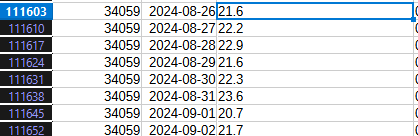

Скриншот из экселя, для проверки вручную

In [924]:
# # --- Добавим колонку month_day для усреднения по дате без года ---
# train_df['month_day'] = train_df['date'].dt.strftime('%m-%d')
# val_df['month_day'] = val_df['date'].dt.strftime('%m-%d')
#
# # --- Историческая средняя по train_df для этих дней ---
# historical_mean = train_df.groupby('month_day')['Средняя температура воздуха'].mean()
#
# # --- Фактическая средняя по дню для val_df (учитываем несколько ВМО на день) ---
# val_daily = val_df.groupby('month_day')['Средняя температура воздуха'].mean()
#
# # --- Строим график ---
# plt.figure(figsize=(12, 6))
#
# # Фактическая температура
# plt.plot(val_daily.index, val_daily.values, label='Фактическая температура (val_df)', marker='o', color='orange')
#
# # Историческая средняя
# plt.plot(historical_mean.loc[val_daily.index].index, historical_mean.loc[val_daily.index].values,
#          label='Историческая средняя (train_df)', marker='x', color='blue')
#
# # Оформление
# plt.xticks(rotation=45)
# plt.xlabel('Дата (месяц-день)')
# plt.ylabel('Средняя температура воздуха')
# plt.title('Фактическая температура vs Историческая средняя')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Удаляем дату

In [925]:
train_df = train_df.drop(columns=['date'])
val_df_drop_date = val_df.drop(columns=['date'])

### Отделяем целевой признак

In [926]:
y_train = train_df['Средняя температура воздуха']
y_val = val_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_val = val_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (108836, 31) (108836,)
Validation shape: (217, 31) (217,)


In [927]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Валидационное:')
print(X_val.isna().sum().sum())
print(y_val.isna().sum().sum())

0
0
Валидационное:
0
0


In [928]:
X_train.columns

Index(['Индекс ВМО', 'Средняя температура воздуха_lag_335',
       'Средняя температура воздуха_lag_365',
       'Средняя температура воздуха_lag_395',
       'Температура поверхности почвы_lag_335',
       'Температура поверхности почвы_lag_365',
       'Температура поверхности почвы_lag_395',
       'Парциальное давление водяного пара_lag_335',
       'Парциальное давление водяного пара_lag_365',
       'Парциальное давление водяного пара_lag_395',
       'Относительная влажность воздуха_lag_335',
       'Относительная влажность воздуха_lag_365',
       'Относительная влажность воздуха_lag_395',
       'Дефицит насыщения водяного пара_lag_335',
       'Дефицит насыщения водяного пара_lag_365',
       'Дефицит насыщения водяного пара_lag_395',
       'Атмосферное давление на уровне моря_lag_335',
       'Атмосферное давление на уровне моря_lag_365',
       'Атмосферное давление на уровне моря_lag_395',
       'Атмосферное давление на уровне станции_lag_335',
       'Атмосферное давлен

## Предсказательные модели

| ugms               | name                  | kod   | широта     | долгота     |
|-------------------|----------------------|-------|-------|-------|
| ПРИВОЛЖСКОЕ УГМС  | САРАТОВ ЮГО-ВОСТОК   | 34172 | 51.57 | 46.0  |
| ПРИВОЛЖСКОЕ УГМС  | ОКТЯБРЬСКИЙ ГОРОДОК  | 34163 | 51.63 | 45.45 |
| ПРИВОЛЖСКОЕ УГМС  | РОСТАШИ              | 34059 | 51.87 | 43.58 |
| ПРИВОЛЖСКОЕ УГМС  | НОВОУЗЕНСК           | 34289 | 50.43 | 48.13 |
| ПРИВОЛЖСКОЕ УГМС  | АЛЕКСАНДРОВ ГАЙ      | 34391 | 50.15 | 48.55 |
| ПРИВОЛЖСКОЕ УГМС  | БАЛАШОВ              | 34152 | 51.55 | 43.15 |
| ПРИВОЛЖСКОЕ УГМС  | ЕРШОВ                | 34186 | 51.37 | 48.3  |

### Метрики оценки точности

#### Стандартные методы

In [929]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

#### Ошибки по дням

In [930]:
def daily_metrics(df_val, y_pred, date_col='date',
                  y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val['prediction'] = y_pred
    results = []

    for date, group in df_val.groupby(date_col):
        y_true = group[y_true_col].values
        y_pred = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам

In [931]:
def metrics_per_index(df_val, y_pred, index_col='Индекс ВМО',
                      y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и индекс
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    metrics_list = []

    for idx, group in df_val.groupby(index_col):
        y_true = group[y_true_col].values
        y_p = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_p)
        rmse = np.sqrt(mean_squared_error(y_true, y_p))
        r2 = r2_score(y_true, y_p)

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    # Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'], color='skyblue')
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE (°C)')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'], color='salmon')
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE (°C)')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'], color='lightgreen')
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [932]:
def cumulative_mae(df_val, y_pred, date_col='date',
                   y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и date
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    # Сортируем по дате
    df_val = df_val.sort_values(date_col)

    # Копим MAE по дням
    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_val.groupby(date_col):
        all_true.extend(group[y_true_col].values)
        all_pred.extend(group[y_pred_col].values)

        mae = mean_absolute_error(all_true, all_pred)
        cum_errors.append({'date': date, 'Cumulative_MAE': mae})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o', linestyle='-')
    plt.xlabel('Дата')
    plt.ylabel('MAE (°C)')
    plt.title('MAE по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Накопление ошибки Mae

In [933]:
def cumulative_error(df_val, y_pred, date_col='date',
                     y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    df_val = df_val.sort_values(date_col)

    cum_errors = []
    total_error = 0

    for date, group in df_val.groupby(date_col):
        daily_error = (group[y_true_col] - group[y_pred_col]).abs().sum()
        total_error += daily_error

        cum_errors.append({'date': date, 'Cumulative_Error': total_error})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_Error'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('Накопленная ошибка')
    plt.title('Накопление абсолютной ошибки по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней

In [934]:
def plot_true_vs_pred(df_val, y_pred, date_col='date', y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    # Усредняем по индексам
    daily_true = df_plot.groupby(date_col)[y_true_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_true.index, daily_true.values, label='Истинная температура', marker='o', linestyle='-', color='blue')
    plt.plot(daily_pred.index, daily_pred.values, label='Предсказанная температура', marker='x', linestyle='--',
             color='orange')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.title('Сравнение истинной и предсказанной температуры')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [935]:
def plot_true_vs_pred_by_index(df_val, y_pred, date_col='date', index_col='Индекс ВМО',
                               y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    indices = df_plot[index_col].unique()
    n_indices = len(indices)

    # Определяем размер подграфиков (по 2 в ряду)
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        ax = axes[i]
        df_idx = df_plot[df_plot[index_col] == idx]
        ax.plot(df_idx[date_col], df_idx[y_true_col], label='Истинная', marker='o', linestyle='-', color='blue')
        ax.plot(df_idx[date_col], df_idx['prediction'], label='Предсказанная', marker='x', linestyle='--',
                color='orange')
        ax.set_title(f'Индекс ВМО: {idx}')
        ax.grid(True, linestyle='--', alpha=0.5)
        if i % n_cols == 0:
            ax.set_ylabel('Температура (°C)')
        ax.legend(fontsize=8)

    # Скрываем лишние пустые графики
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### XGBRegressor

In [936]:
# Создаем DMatrix для XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Параметры модели
params = {
    'objective': 'reg:squarederror',  # регрессия
    'eval_metric': 'rmse',
    'eta': 0.1,  # learning rate
    'max_depth': 6,  # глубина деревьев
    'subsample': 0.8,  # случайная подвыборка для предотвращения переобучения
    'colsample_bytree': 0.8,
    'seed': 42
}

# Обучение с ранней остановкой
evals = [(dtrain, 'train'), (dval, 'validation')]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=50
)

# Предсказание на валидации
y_pred = xgb_model.predict(dval)
xgb_result = simple_metric(y_val, y_pred)
xgb_result

[0]	train-rmse:11.56377	validation-rmse:11.37627
[50]	train-rmse:4.25074	validation-rmse:4.07068
[92]	train-rmse:3.96535	validation-rmse:4.01050
Простые метрики:
MAE: 3.3465
MSE: 16.0841
RMSE: 4.0105
MAPE: 17.82%
R²: -0.2207


{'MAE': 3.3465331178656363,
 'MSE': 16.08407613962498,
 'RMSE': np.float64(4.010495747364032),
 'MAPE': np.float64(17.815476248987647),
 'R2': -0.22073752463256602}

In [937]:
df_compare = pd.DataFrame({
    'y_true': y_val,
    'y_pred': y_pred
})

df_compare.head(5)

,y_true,y_pred
15548,21.6,18.571455
15549,22.2,17.206717
15550,22.9,17.674780
15551,21.6,18.092052
15552,22.3,18.182028


#### Важность признаков


                                        feature     importance
29       Средняя температура воздуха_mean_group  114441.281250
26                                       season   96734.562500
2           Средняя температура воздуха_lag_365   44156.871094
25                              day_of_year_cos   28810.601562
24                              day_of_year_sin    4558.949707
27                                    month_sin    4278.814453
22                                         year    1431.900757
4         Температура поверхности почвы_lag_335    1268.502808
30                   temp_delta_vs_all_stations    1151.515747
28                                    month_cos    1084.443848
6         Температура поверхности почвы_lag_395     919.569275
23                                          day     693.666199
16  Атмосферное давление на уровне моря_lag_335     658.252625
7    Парциальное давление водяного пара_lag_335     611.238770
3           Средняя температура воздуха_lag_395     608

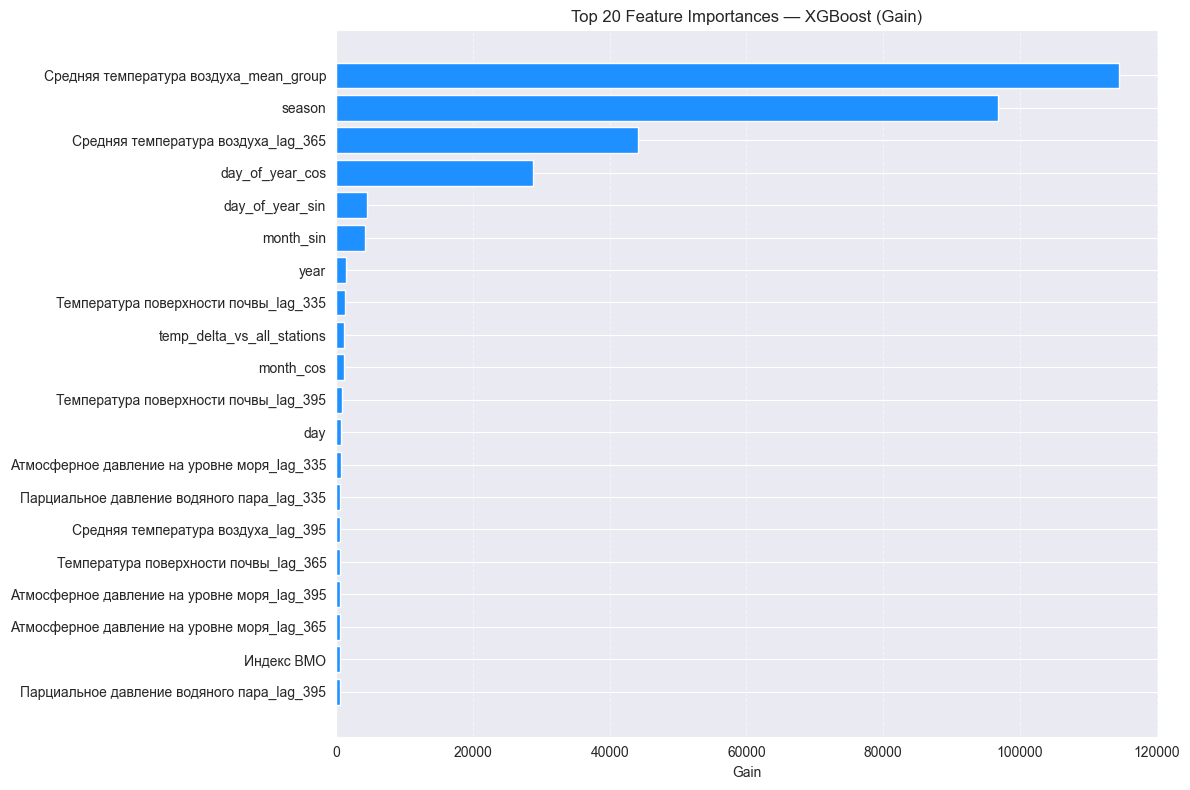

In [938]:
gain_importances = xgb_model.get_score(importance_type='gain')

fi_df = pd.DataFrame({
    'feature': list(gain_importances.keys()),
    'importance': list(gain_importances.values())
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBoost (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Оценка точности

In [939]:
# daily_metrics(val_df, y_pred)

In [940]:
# mae_index_df = metrics_per_index(val_df, y_pred)

Для Саратова хуже всего

In [941]:
# cum_mae_df = cumulative_mae(val_df, y_pred)

In [942]:
# cum_mae_df = cumulative_error(val_df, y_pred)

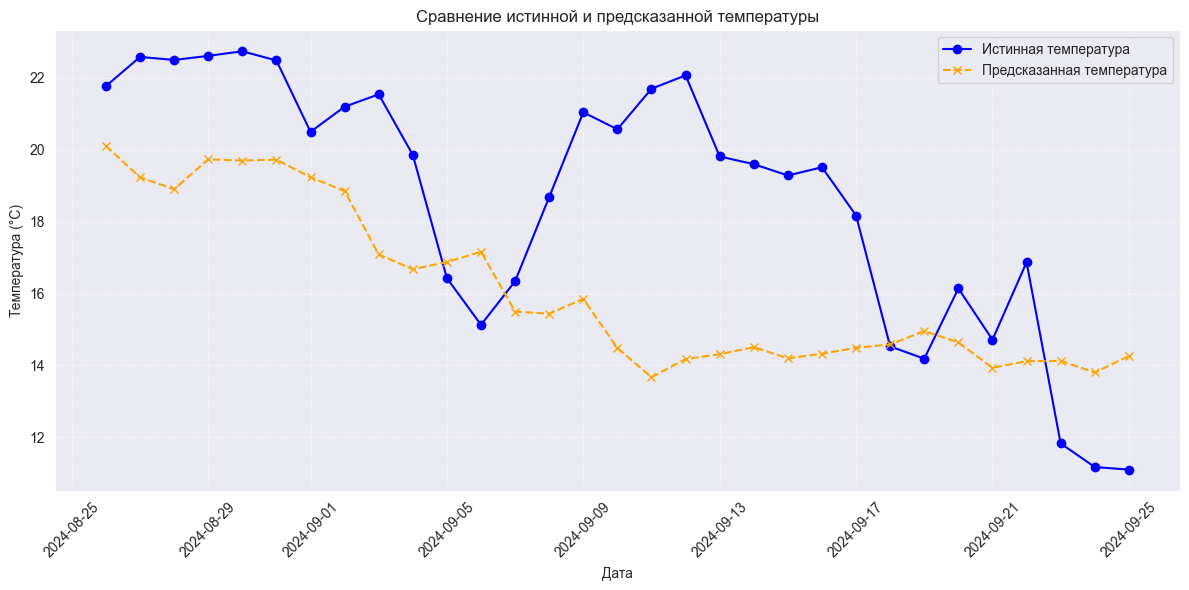

In [943]:
plot_true_vs_pred(val_df, y_pred)

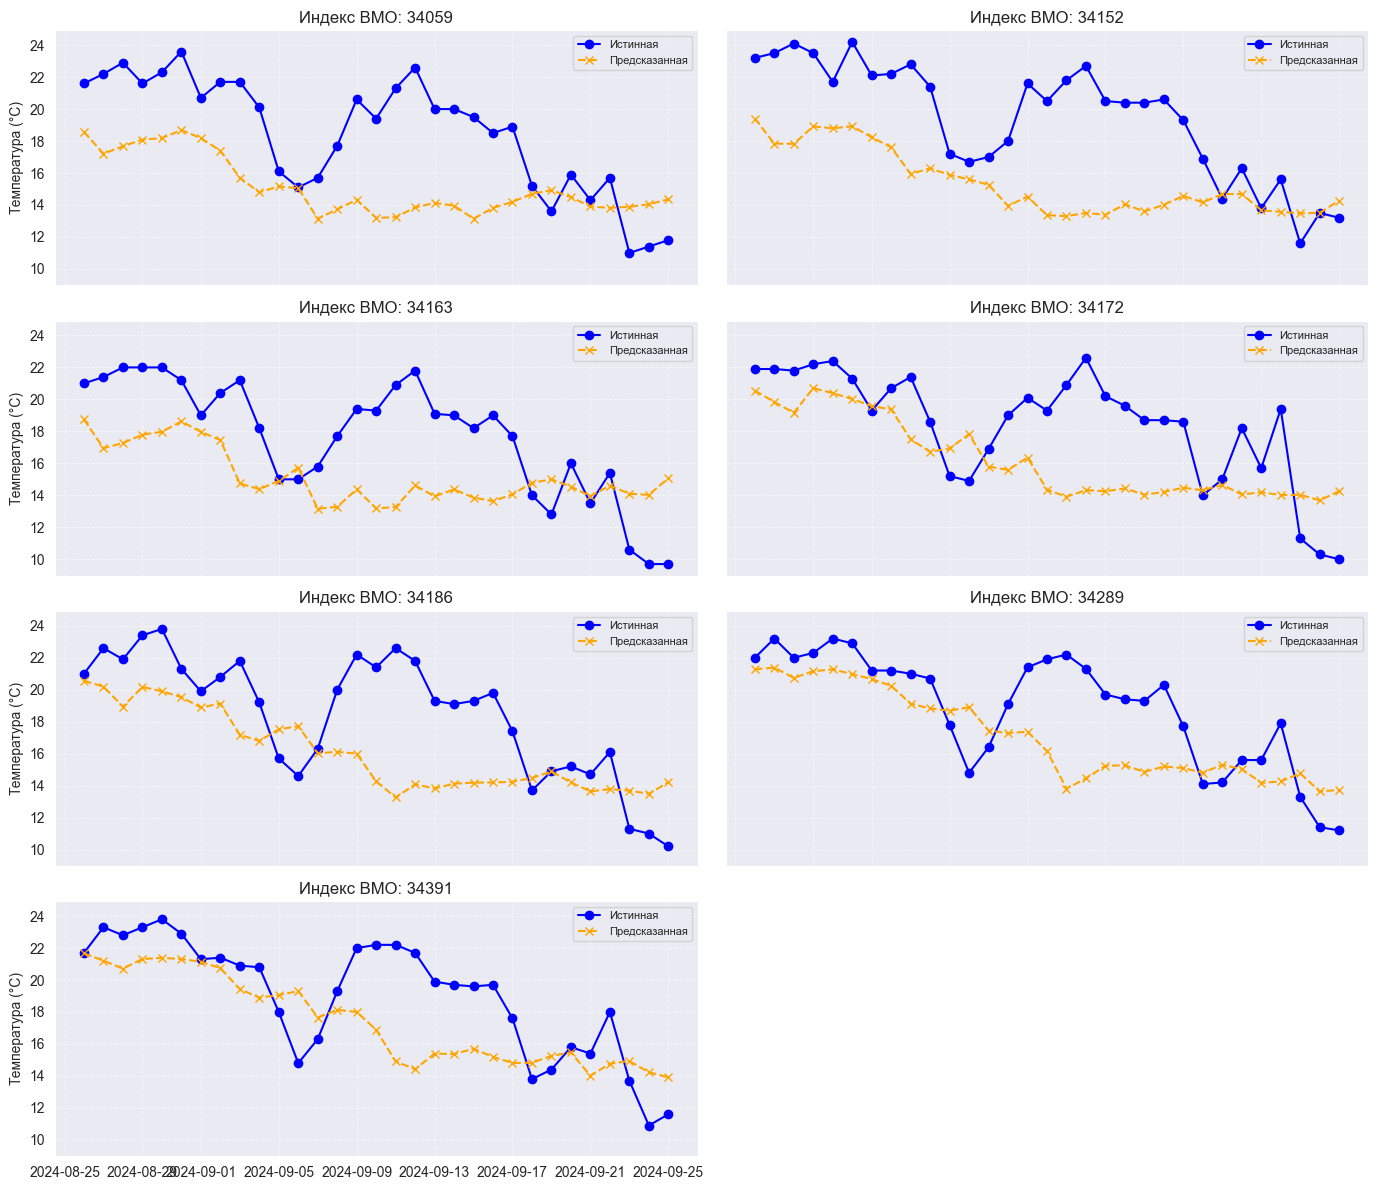

In [944]:
plot_true_vs_pred_by_index(val_df, y_pred)

### LightGBM

In [945]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

# Параметры (максимально близко к XGBoost)
params = {
    'objective': 'regression',  # аналог reg:squarederror
    'metric': 'rmse',
    'learning_rate': 0.1,  # eta
    'max_depth': 6,
    'feature_fraction': 0.8,  # colsample_bytree
    'bagging_fraction': 0.8,  # subsample
    'bagging_freq': 1,
    'seed': 42,
    'verbosity': -1
}

# Обучение с early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=50)
    ]
)

# Предсказание
y_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Метрика
lgb_result = simple_metric(y_val, y_pred)
lgb_result

Training until validation scores don't improve for 20 rounds
[50]	train's rmse: 4.40987	validation's rmse: 4.01877
Early stopping, best iteration is:
[63]	train's rmse: 4.34229	validation's rmse: 3.97215
Простые метрики:
MAE: 3.3715
MSE: 15.7780
RMSE: 3.9722
MAPE: 17.82%
R²: -0.1975


{'MAE': 3.371542105405551,
 'MSE': 15.777988019367065,
 'RMSE': np.float64(3.972151560472871),
 'MAPE': np.float64(17.817341673790516),
 'R2': -0.19750627087578088}

#### Важность признаков


                                        feature    importance
29       Средняя температура воздуха_mean_group  4.133320e+07
25                              day_of_year_cos  1.672027e+07
24                              day_of_year_sin  2.671625e+06
22                                         year  1.306288e+06
5         Температура поверхности почвы_lag_365  9.586063e+05
26                                       season  3.925912e+05
28                                    month_cos  1.122013e+05
16  Атмосферное давление на уровне моря_lag_335  1.111883e+05
6         Температура поверхности почвы_lag_395  1.009105e+05
23                                          day  9.853323e+04
18  Атмосферное давление на уровне моря_lag_395  8.750000e+04
17  Атмосферное давление на уровне моря_lag_365  7.930317e+04
3           Средняя температура воздуха_lag_395  6.979014e+04
27                                    month_sin  6.333808e+04
7    Парциальное давление водяного пара_lag_335  5.418754e+04
1       

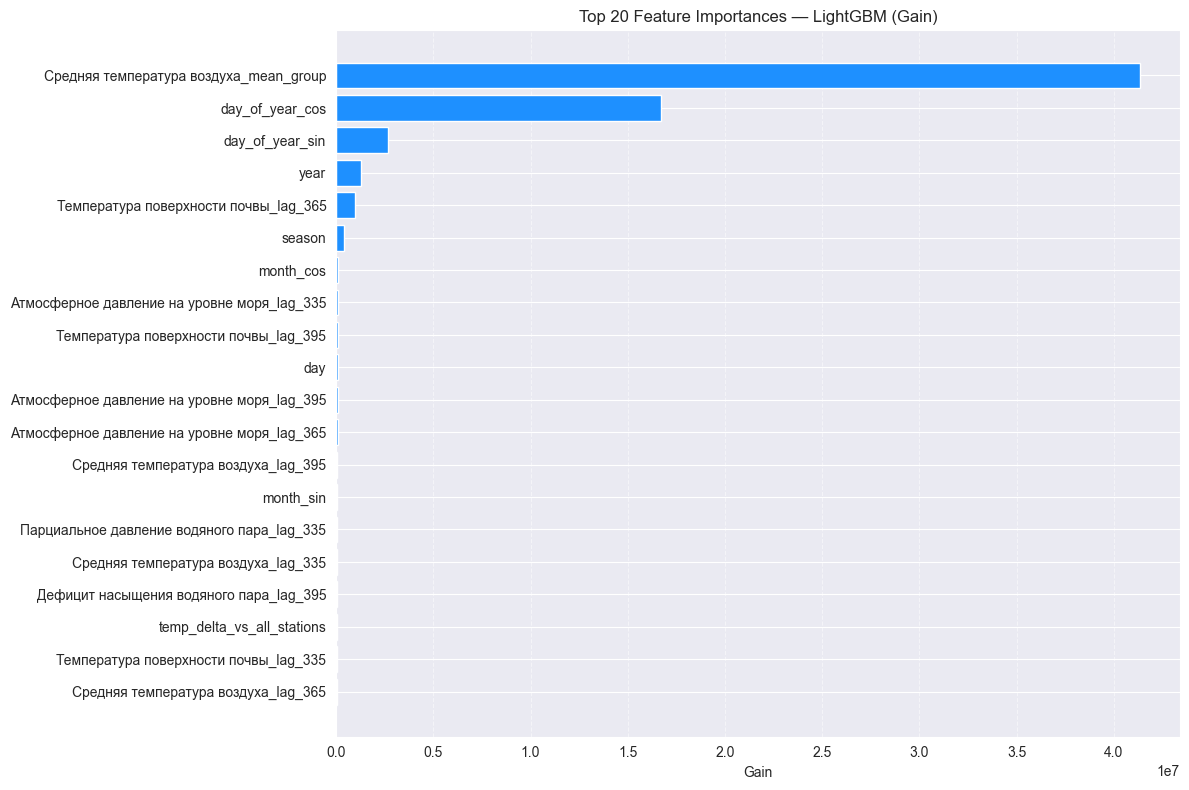

In [946]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

# Создаём DataFrame
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — LightGBM (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### HistGradientBoostingRegressor

In [947]:
model = HistGradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    max_depth=6,
    max_iter=500,
    max_bins=255,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.2,  # ← ВАЖНО
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

hist_result = simple_metric(y_val, y_pred)
hist_result

Binning 0.022 GB of training data: 0.069 s
Binning 0.005 GB of validation data: 0.007 s
Fitting gradient boosted rounds:
Fit 500 trees in 3.377 s, (15460 total leaves)
Time spent computing histograms: 1.436s
Time spent finding best splits:  0.368s
Time spent applying splits:      0.614s
Time spent predicting:           0.070s
Простые метрики:
MAE: 3.3139
MSE: 15.9959
RMSE: 3.9995
MAPE: 17.30%
R²: -0.2140


{'MAE': 3.3138535667539006,
 'MSE': 15.99589860652668,
 'RMSE': np.float64(3.999487292957271),
 'MAPE': np.float64(17.30367517014997),
 'R2': -0.21404509029265162}

### CatBoostRegressor

In [948]:
# Модель (параметры максимально близки к XGBoost)
model = CatBoostRegressor(
    loss_function='RMSE',
    learning_rate=0.1,
    depth=6,
    iterations=500,
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    verbose=50
)

# Обучение с early stopping
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20,
    use_best_model=True
)

# Предсказание
y_pred = model.predict(X_val)

# Метрика
cat_result = simple_metric(y_val, y_pred)
cat_result

0:	learn: 11.6137182	test: 11.3838612	best: 11.3838612 (0)	total: 11.1ms	remaining: 5.55s
50:	learn: 4.7426342	test: 3.5727137	best: 3.5719513 (48)	total: 576ms	remaining: 5.07s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 3.491953261
bestIteration = 72

Shrink model to first 73 iterations.
Простые метрики:
MAE: 2.9786
MSE: 12.1937
RMSE: 3.4920
MAPE: 15.93%
R²: 0.0745


{'MAE': 2.9785588109875736,
 'MSE': 12.193737481309025,
 'RMSE': np.float64(3.4919532472971375),
 'MAPE': np.float64(15.927021534184957),
 'R2': 0.07452857225161136}

#### Важность признаков

                                        feature  importance
29       Средняя температура воздуха_mean_group   61.288729
22                                         year   10.354314
25                              day_of_year_cos    7.648997
26                                       season    3.180855
24                              day_of_year_sin    2.996695
28                                    month_cos    2.561593
27                                    month_sin    2.312848
3           Средняя температура воздуха_lag_395    1.238603
6         Температура поверхности почвы_lag_395    0.991912
16  Атмосферное давление на уровне моря_lag_335    0.836127
5         Температура поверхности почвы_lag_365    0.787438
9    Парциальное давление водяного пара_lag_395    0.730828
4         Температура поверхности почвы_lag_335    0.597504
7    Парциальное давление водяного пара_lag_335    0.566277
30                   temp_delta_vs_all_stations    0.446490
23                                      

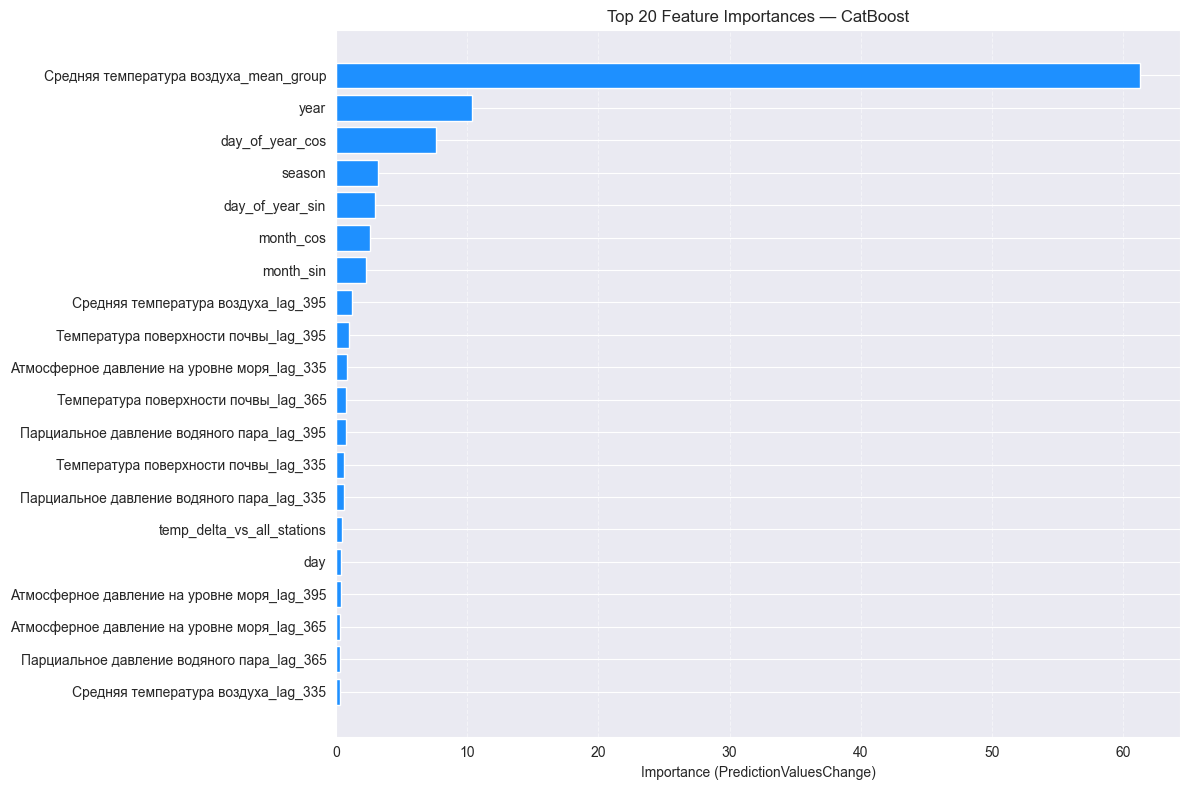

In [949]:
# Получаем важность признаков по 'PredictionValuesChange' (аналог Gain)
gain_importances = model.get_feature_importance(type='PredictionValuesChange')
feature_names = X_train.columns

# Создаём DataFrame
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Importance (PredictionValuesChange)')
plt.title('Top 20 Feature Importances — CatBoost')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### RandomForestRegressor

In [950]:
# Модель (параметры максимально приближены по смыслу к XGBoost)
model = RandomForestRegressor(
    n_estimators=500,  # аналог num_boost_round (кол-во деревьев)
    max_depth=6,
    max_features=0.8,  # аналог colsample_bytree
    bootstrap=True,  # аналог subsample
    random_state=42,
    n_jobs=-1,  # использовать все ядра
    verbose=1
)

# Обучение
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_val)

rf_result = simple_metric(y_val, y_pred)
rf_result

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:   32.0s


Простые метрики:
MAE: 3.4774
MSE: 16.9929
RMSE: 4.1222
MAPE: 18.39%
R²: -0.2897


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   36.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


{'MAE': 3.4773530856473402,
 'MSE': 16.99292412977547,
 'RMSE': np.float64(4.122247461006613),
 'MAPE': np.float64(18.392531047725395),
 'R2': -0.2897166090470138}

## Результаты

In [951]:
results = []

if 'xgb_result' in globals():
    results.append({'model': 'XGBoost', **xgb_result})

if 'lgb_result' in globals():
    results.append({'model': 'LightGBM', **lgb_result})

if 'hist_result' in globals():
    results.append({'model': 'HistGB', **hist_result})

if 'cat_result' in globals():
    results.append({'model': 'CatBoost', **cat_result})

if 'rf_result' in globals():
    results.append({'model': 'RandomForest', **rf_result})

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='MAE').reset_index(drop=True)

df_results

,model,MAE,MSE,RMSE,MAPE,R2
0,CatBoost,2.978559,12.193737,3.491953,15.927022,0.074529
1,HistGB,3.313854,15.995899,3.999487,17.303675,-0.214045
2,XGBoost,3.346533,16.084076,4.010496,17.815476,-0.220738
3,LightGBM,3.371542,15.777988,3.972152,17.817342,-0.197506
4,RandomForest,3.477353,16.992924,4.122247,18.392531,-0.289717


In [952]:
df_results['MAE'][:3].sum()

np.float64(9.63894549560711)

In [953]:
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

with open("log.md", "a", encoding="utf-8") as f:
    f.write(f"\n\n## Run at {now}\n\n")
    f.write(df_results.to_markdown())
    f.write(f"\nПервые 3 MAE: {str(float(df_results['MAE'][:3].sum()))}")